In [1]:
from pathlib import Path
import json

import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

ROOT     = Path().resolve().parent
OBT      = ROOT / 'data' / 'gold' / 'obt.parquet'
FINDINGS = ROOT / 'data' / 'gold' / 'product_region_findings.json'

conn = duckdb.connect()
conn.execute(f"CREATE VIEW obt AS SELECT * FROM read_parquet('{OBT}')")

df = conn.execute('SELECT * FROM obt').df()
df['date']    = pd.to_datetime(df['date'])
df['year']    = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
df['month']   = df['date'].dt.month
df['q_label'] = 'Q' + df['quarter'].astype(str)
df['periodo'] = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)
df['mes_str'] = df['date'].dt.to_period('M').astype(str)

with open(FINDINGS) as f:
    findings = json.load(f)

BLUE   = '#1f77b4'
RED    = '#d62728'
GREEN  = '#2ca02c'
ORANGE = '#ff7f0e'
GRAY   = '#aaaaaa'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size': 11,
})

---
# Diagnostico: Supply Chain Ball Corporation

Este notebook demonstra os 5 achados centrais da analise, com foco em **por que o OTIF e baixo** e **onde esta a oportunidade de melhoria**.

---
## 1. O problema nao e falta de estoque — e distribuicao errada

Em todas as regioes e produtos, stockout e overflow coexistem no mesmo periodo. O estoque existe — esta no lugar errado.

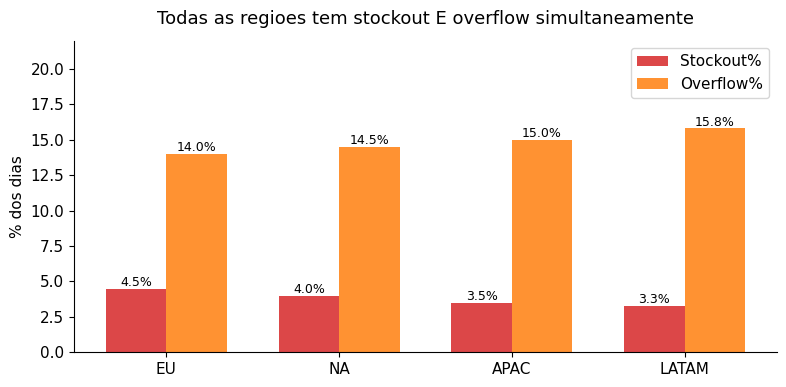

In [2]:
# Stockout vs overflow por regiao (geral)
flags_reg = (
    df.groupby('region')
    .agg(
        pct_stockout=('stockout_flag', lambda x: round(100 * x.mean(), 1)),
        pct_overflow=('overflow_flag', lambda x: round(100 * x.mean(), 1)),
    )
    .reset_index()
    .sort_values('pct_stockout', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(flags_reg))
w = 0.35
ax.bar(x - w/2, flags_reg['pct_stockout'], w, label='Stockout%', color=RED,   alpha=0.85)
ax.bar(x + w/2, flags_reg['pct_overflow'], w, label='Overflow%', color=ORANGE, alpha=0.85)

for i, row in flags_reg.reset_index(drop=True).iterrows():
    ax.text(i - w/2, row['pct_stockout'] + 0.2, f"{row['pct_stockout']}%", ha='center', fontsize=9)
    ax.text(i + w/2, row['pct_overflow'] + 0.2, f"{row['pct_overflow']}%", ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(flags_reg['region'])
ax.set_ylabel('% dos dias')
ax.set_title('Todas as regioes tem stockout E overflow simultaneamente', fontsize=13, pad=12)
ax.legend()
ax.set_ylim(0, 22)
plt.tight_layout()
plt.show()

In [3]:
# Dias em que EU tem stockout enquanto LATAM tem overflow — mesmo produto, mesmo dia
eu_stockout = df[(df['region'] == 'EU') & (df['stockout_flag'])][['date', 'product']].rename(columns={'product': 'prod'})
latam_overflow = df[(df['region'] == 'LATAM') & (df['overflow_flag'])][['date', 'product', 'stock_level']]

deseq = eu_stockout.merge(latam_overflow, left_on=['date', 'prod'], right_on=['date', 'product'])

print('Dias em que EU tem stockout e LATAM tem overflow no MESMO produto:')
resumo = deseq.groupby('prod').agg(
    dias=('date', 'nunique'),
    estoque_latam_medio=('stock_level', 'mean')
).round(0).astype({'dias': int, 'estoque_latam_medio': int})
print(resumo)

total_unid = int(deseq['stock_level'].sum())
print(f'\nTotal de unidades paradas em LATAM nesses dias: {total_unid:,}')
print('Essas unidades poderiam ter abastecido EU em ruptura.')

Dias em que EU tem stockout e LATAM tem overflow no MESMO produto:
      dias  estoque_latam_medio
prod                           
A        3                11612
B        8                11640
C        8                11716

Total de unidades paradas em LATAM nesses dias: 221,691
Essas unidades poderiam ter abastecido EU em ruptura.


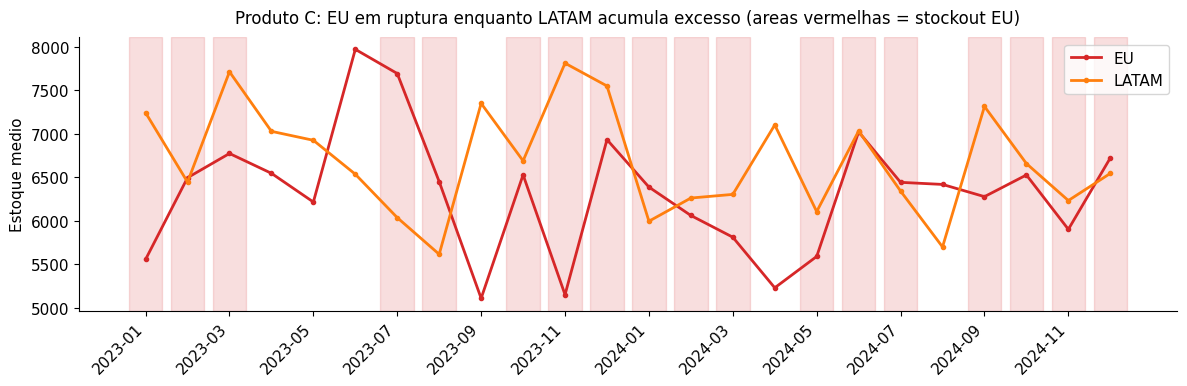

In [4]:
# Estoque medio mensal EU vs LATAM para produto C — o caso mais critico
prod_foco = 'C'
eu_c    = df[(df['product'] == prod_foco) & (df['region'] == 'EU')].groupby('mes_str')['stock_level'].mean()
latam_c = df[(df['product'] == prod_foco) & (df['region'] == 'LATAM')].groupby('mes_str')['stock_level'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eu_c.index, eu_c.values,    color=RED,  lw=2, marker='o', markersize=3, label='EU')
ax.plot(latam_c.index, latam_c.values, color=ORANGE, lw=2, marker='o', markersize=3, label='LATAM')

# marcar periodos em que EU esta em stockout (stock_level = 0)
eu_zero = df[(df['product'] == prod_foco) & (df['region'] == 'EU') & (df['stockout_flag'])]['mes_str'].unique()
for m in eu_zero:
    ax.axvspan(list(eu_c.index).index(m) - 0.4,
               list(eu_c.index).index(m) + 0.4,
               alpha=0.15, color=RED)

ax.set_title(f'Produto {prod_foco}: EU em ruptura enquanto LATAM acumula excesso (areas vermelhas = stockout EU)', fontsize=12, pad=10)
ax.set_ylabel('Estoque medio')
ax.set_xticks(range(0, len(eu_c), 2))
ax.set_xticklabels(list(eu_c.index)[::2], rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Produto C e o mais critico do portfolio

Pior OTIF, maior numero de dias em desequilibrio, e concentracao de problemas no Q4.

/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_63447/1162553226.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df['total_pedidos'] > 0]


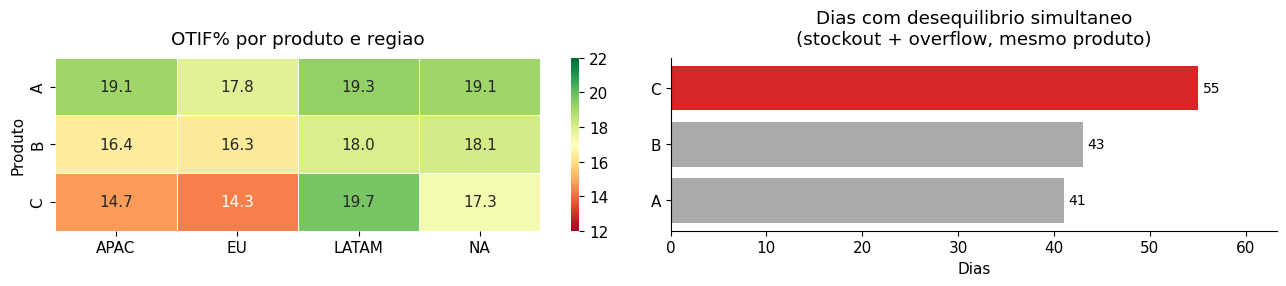

In [5]:
# OTIF por produto x regiao
otif_pr = (
    df[df['total_pedidos'] > 0]
    .groupby(['product', 'region'])
    .apply(lambda g: round(100 * g['pedidos_on_time'].sum() / g['total_pedidos'].sum(), 1))
    .unstack('region')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

sns.heatmap(
    otif_pr, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=12, vmax=22, linewidths=0.5, ax=axes[0]
)
axes[0].set_title('OTIF% por produto e regiao', pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Produto')

# Dias de desequilibrio por produto
imb = pd.Series(findings['total_dias_desequilibrio_por_produto']).sort_values(ascending=True)
colors_bar = [RED if p == 'C' else GRAY for p in imb.index]
axes[1].barh(imb.index, imb.values, color=colors_bar)
for i, (prod, val) in enumerate(imb.items()):
    axes[1].text(val + 0.5, i, str(val), va='center', fontsize=10)
axes[1].set_title('Dias com desequilibrio simultaneo\n(stockout + overflow, mesmo produto)', pad=10)
axes[1].set_xlabel('Dias')
axes[1].set_xlim(0, imb.max() * 1.15)

plt.tight_layout()
plt.show()

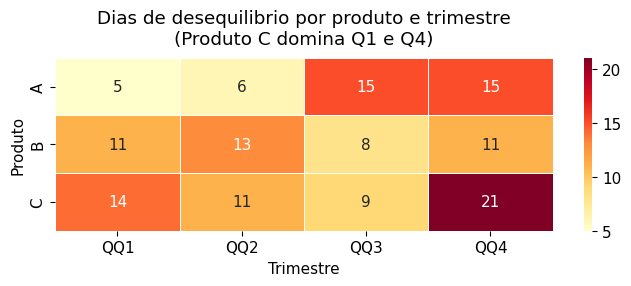

In [6]:
# Desequilibrio por produto x trimestre — C domina o Q4
imb_q_raw = findings['desequilibrio_por_produto_trimestre']
imb_q = pd.DataFrame({
    f'Q{k.replace("QQ","")}': v for k, v in imb_q_raw.items()
}).T
imb_q = imb_q.reindex(sorted(imb_q.index))

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(
    imb_q.T.astype(int), annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax
)
ax.set_title('Dias de desequilibrio por produto e trimestre\n(Produto C domina Q1 e Q4)', pad=10)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Produto')
plt.tight_layout()
plt.show()

---
## 3. EU e a regiao mais vulneravel — reposicao tardia, nao demanda alta

EU lidera o stockout em quase todos os produtos. A causa nao e demanda excepcional: o nivel de estoque de EU nao se coordena com nenhuma outra regiao.

/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_63447/2790882710.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df['total_pedidos'] > 0]


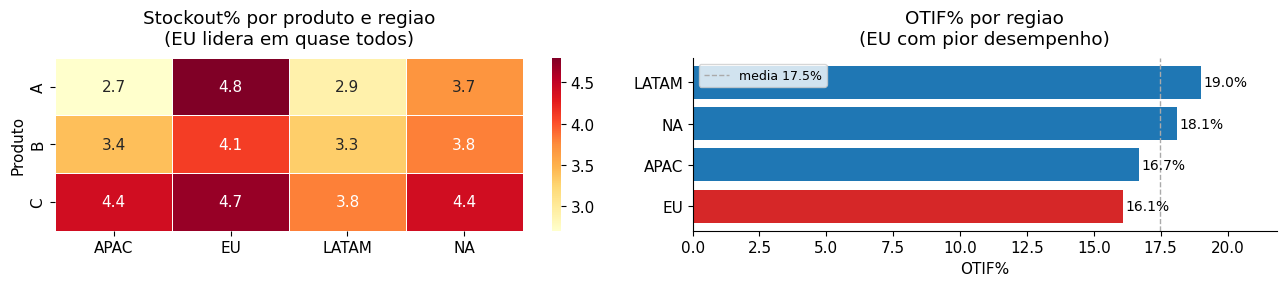

In [7]:
# Stockout por regiao x produto
stockout_pr = (
    df.groupby(['product', 'region'])['stockout_flag']
    .mean().mul(100).round(1)
    .unstack('region')
)

# OTIF por regiao (media de produtos)
otif_reg = (
    df[df['total_pedidos'] > 0]
    .groupby('region')
    .apply(lambda g: round(100 * g['pedidos_on_time'].sum() / g['total_pedidos'].sum(), 1))
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

sns.heatmap(
    stockout_pr, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Stockout% por produto e regiao\n(EU lidera em quase todos)', pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Produto')

colors_reg = [RED if r == 'EU' else BLUE for r in otif_reg.index]
axes[1].barh(otif_reg.index, otif_reg.values, color=colors_reg)
for i, (reg, val) in enumerate(otif_reg.items()):
    axes[1].text(val + 0.1, i, f'{val}%', va='center', fontsize=10)
axes[1].axvline(otif_reg.mean(), color=GRAY, linestyle='--', lw=1, label=f'media {otif_reg.mean():.1f}%')
axes[1].set_title('OTIF% por regiao\n(EU com pior desempenho)', pad=10)
axes[1].set_xlabel('OTIF%')
axes[1].set_xlim(0, otif_reg.max() * 1.15)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

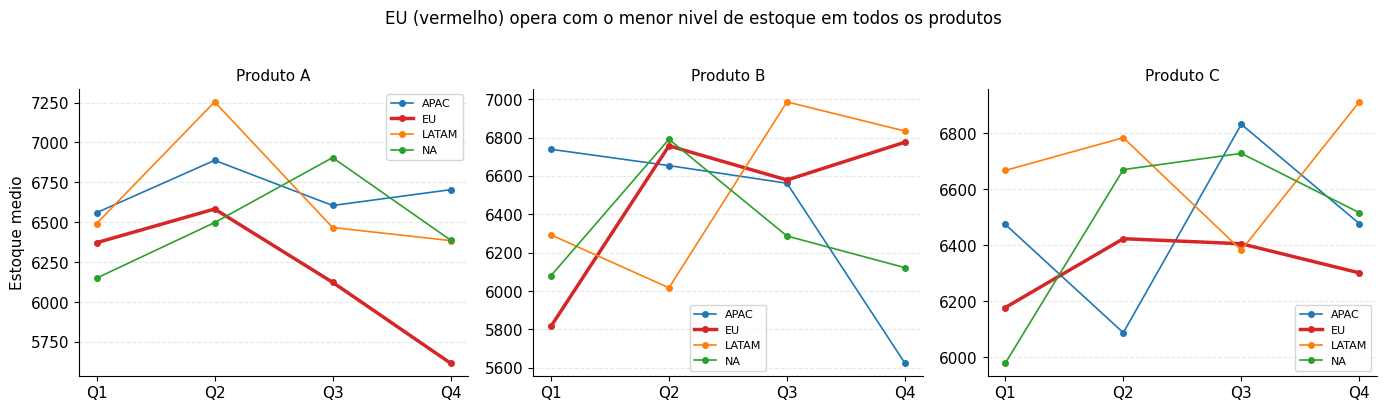

In [8]:
# Evolucao trimestral do estoque EU vs demais regioes — por produto
estoque_q = (
    df.groupby(['q_label', 'region', 'product'])['stock_level']
    .mean().round(0).reset_index()
)

PRODUCTS = sorted(df['product'].unique())
REGIONS  = sorted(df['region'].unique())
colors_map = {'APAC': BLUE, 'EU': RED, 'LATAM': ORANGE, 'NA': GREEN}

fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4), sharey=False)
for ax, prod in zip(axes, PRODUCTS):
    dp = estoque_q[estoque_q['product'] == prod]
    for reg in REGIONS:
        dr = dp[dp['region'] == reg]
        lw = 2.5 if reg == 'EU' else 1.2
        ax.plot(dr['q_label'], dr['stock_level'], marker='o', markersize=4,
                label=reg, color=colors_map[reg], lw=lw)
    ax.set_title(f'Produto {prod}', fontsize=11)
    ax.set_ylabel('Estoque medio' if prod == PRODUCTS[0] else '')
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

fig.suptitle('EU (vermelho) opera com o menor nivel de estoque em todos os produtos', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Q3 e Q4 amplificam o problema de forma diferente por produto

Nao ha um unico pico sazonal — cada produto tem seu padrao. Uma politica unica de reposicao nao resolve.

/var/folders/vv/x90vqwmn3xz8wyp1hqkb0rr40000gn/T/ipykernel_63447/2908754383.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df['total_pedidos'] > 0]


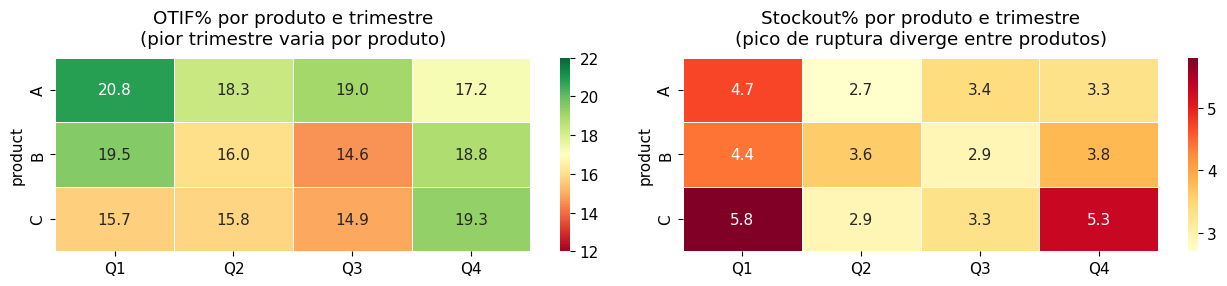

Pior trimestre por produto (OTIF):
  Produto A: pior = Q4 (17.2%) | melhor = Q1 (20.8%) | delta = 3.6pp
  Produto B: pior = Q3 (14.6%) | melhor = Q1 (19.5%) | delta = 4.9pp
  Produto C: pior = Q3 (14.9%) | melhor = Q4 (19.3%) | delta = 4.4pp


In [9]:
# OTIF por produto x trimestre
otif_pq = (
    df[df['total_pedidos'] > 0]
    .groupby(['product', 'q_label'])
    .apply(lambda g: round(100 * g['pedidos_on_time'].sum() / g['total_pedidos'].sum(), 1))
    .unstack('q_label')
)

# Stockout por produto x trimestre
stockout_pq = (
    df.groupby(['product', 'q_label'])['stockout_flag']
    .mean().mul(100).round(1)
    .unstack('q_label')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

sns.heatmap(
    otif_pq, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=12, vmax=22, linewidths=0.5, ax=axes[0]
)
axes[0].set_title('OTIF% por produto e trimestre\n(pior trimestre varia por produto)', pad=10)
axes[0].set_xlabel('')

sns.heatmap(
    stockout_pq, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Stockout% por produto e trimestre\n(pico de ruptura diverge entre produtos)', pad=10)
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print('Pior trimestre por produto (OTIF):')
for prod in PRODUCTS:
    pior_q = otif_pq.loc[prod].idxmin()
    pior_v = otif_pq.loc[prod].min()
    melhor_q = otif_pq.loc[prod].idxmax()
    melhor_v = otif_pq.loc[prod].max()
    print(f'  Produto {prod}: pior = {pior_q} ({pior_v}%) | melhor = {melhor_q} ({melhor_v}%) | delta = {melhor_v - pior_v:.1f}pp')

---
## 5. Correlacao proxima de zero confirma ausencia de planejamento integrado

Em uma cadeia coordenada, regioes que compartilham o mesmo produto deveriam ter correlacao de estoque positiva (reposicao sincronizada) ou negativa estruturada (redistribuicao ativa). O que vemos e ruido puro — cada regiao opera de forma completamente independente.

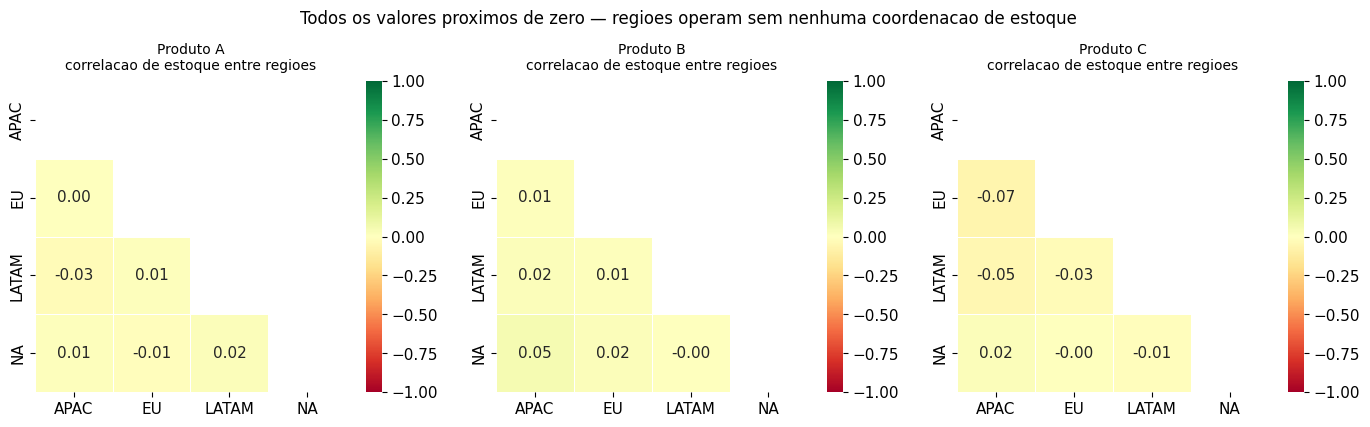

In [10]:
fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4))

for ax, prod in zip(axes, PRODUCTS):
    pivot = (
        df[df['product'] == prod]
        .groupby(['date', 'region'])['stock_level']
        .mean().unstack('region')
    )
    corr = pivot.corr().round(2)
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, annot=True, fmt='.2f', cmap='RdYlGn',
        vmin=-1, vmax=1, mask=mask,
        linewidths=0.5, ax=ax, square=True
    )
    ax.set_title(f'Produto {prod}\ncorrelacao de estoque entre regioes', fontsize=10, pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle(
    'Todos os valores proximos de zero — regioes operam sem nenhuma coordenacao de estoque',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

In [11]:
# Resumo quantitativo: o que seria possivel com redistribuicao
# Para cada dia de stockout em EU: quanto havia disponivel nas demais regioes com overflow?

eu_stockout_days = df[(df['region'] == 'EU') & (df['stockout_flag'])][['date', 'product']]
outras_overflow  = df[(df['region'] != 'EU') & (df['overflow_flag'])][['date', 'product', 'region', 'stock_level']]

potencial = (
    eu_stockout_days
    .merge(outras_overflow, on=['date', 'product'])
    .groupby('product')
    .agg(
        dias_cobertos=('date', 'nunique'),
        unidades_disponiveis=('stock_level', 'sum'),
        regiao_principal=('region', lambda x: x.value_counts().idxmax())
    )
)
potencial['unidades_disponiveis'] = potencial['unidades_disponiveis'].apply(lambda x: f'{int(x):,}')

print('Dias em que EU estava em stockout E outra regiao tinha overflow do mesmo produto:')
print(potencial.to_string())
print('\nEm todos os casos, havia estoque disponivel em outra regiao para cobrir a ruptura.')
print('O problema nao e producao insuficiente — e ausencia de mecanismo de redistribuicao.')

Dias em que EU estava em stockout E outra regiao tinha overflow do mesmo produto:
         dias_cobertos unidades_disponiveis regiao_principal
product                                                     
A                   10              135,936             APAC
B                   15              181,303            LATAM
C                   16              204,758            LATAM

Em todos os casos, havia estoque disponivel em outra regiao para cobrir a ruptura.
O problema nao e producao insuficiente — e ausencia de mecanismo de redistribuicao.


---
## Conclusao consolidada

| Achado | Evidencia | Impacto |
|---|---|---|
| Estoque mal distribuido | EU em stockout enquanto LATAM/APAC em overflow — mesmo produto, mesmo dia | Direto no OTIF |
| Produto C mais critico | Pior OTIF (14.3% EU), 55 dias de desequilibrio, dominancia no Q4 | Portfolio |
| EU mais vulneravel | Lidera stockout em todos os produtos, menor nivel de estoque medio | Regional |
| Sazonalidade diferente por produto | Produto A piora no Q3/Q4, Produto C piora no Q4, Produto B mais estavel | Planejamento |
| Ausencia de coordenacao | Correlacoes proximas de zero entre regioes para o mesmo produto | Sistemico |

**A causa raiz do OTIF de 17.5% e a ausencia de visibilidade compartilhada entre regioes.**  
O estoque existe. A producao existe. O que falta e um mecanismo que identifique o desequilibrio e acione a redistribuicao antes que a ruptura aconteca.